In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcdefaults()

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5,
    'lines.markersize': 9,
    'savefig.dpi': 300,
})

SEASONS = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11]
}
SEASON_COLORS = {'DJF': '#5b8ec4', 'MAM': '#6abf69', 'JJA': '#e07b3a', 'SON': '#c17bca'}

print('Imports OK')

Imports OK


In [167]:
temp = pd.read_csv("/home/group3/teaching-materials/Main_project/ERA5_Temp_1980_2026.csv")
evap = pd.read_csv("/home/group3/teaching-materials/Main_project/Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv")
precip = pd.read_csv("/home/group3/teaching-materials/Main_project/Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv")

# Convert YYYYMM → datetime
temp['date'] = pd.to_datetime(temp['system:index'], format="%Y%m")
evap['date'] = pd.to_datetime(evap['system:index'], format="%Y%m")
precip['date'] = pd.to_datetime(precip['system:index'], format="%Y%m")

# Keep only needed columns
temp = temp[['date', 'temperature_2m']]
evap = evap[['date', 'total_evaporation_sum']]
precip = precip[['date', 'total_precipitation_sum']]

# Merge
df = temp.merge(evap, on='date').merge(precip, on='date')

# Rename
df = df.rename(columns={
    'temperature_2m': 'temp',
    'total_evaporation_sum': 'et',
    'total_precipitation_sum': 'precip'
})

# Convert Kelvin → Celsius
df['temp'] = df['temp'] - 273.15

# Flip ET so evaporation is positive
df['et'] = -df['et']*1000
# Set index
df = df.set_index('date').sort_index()
df['month'] = df.index.month



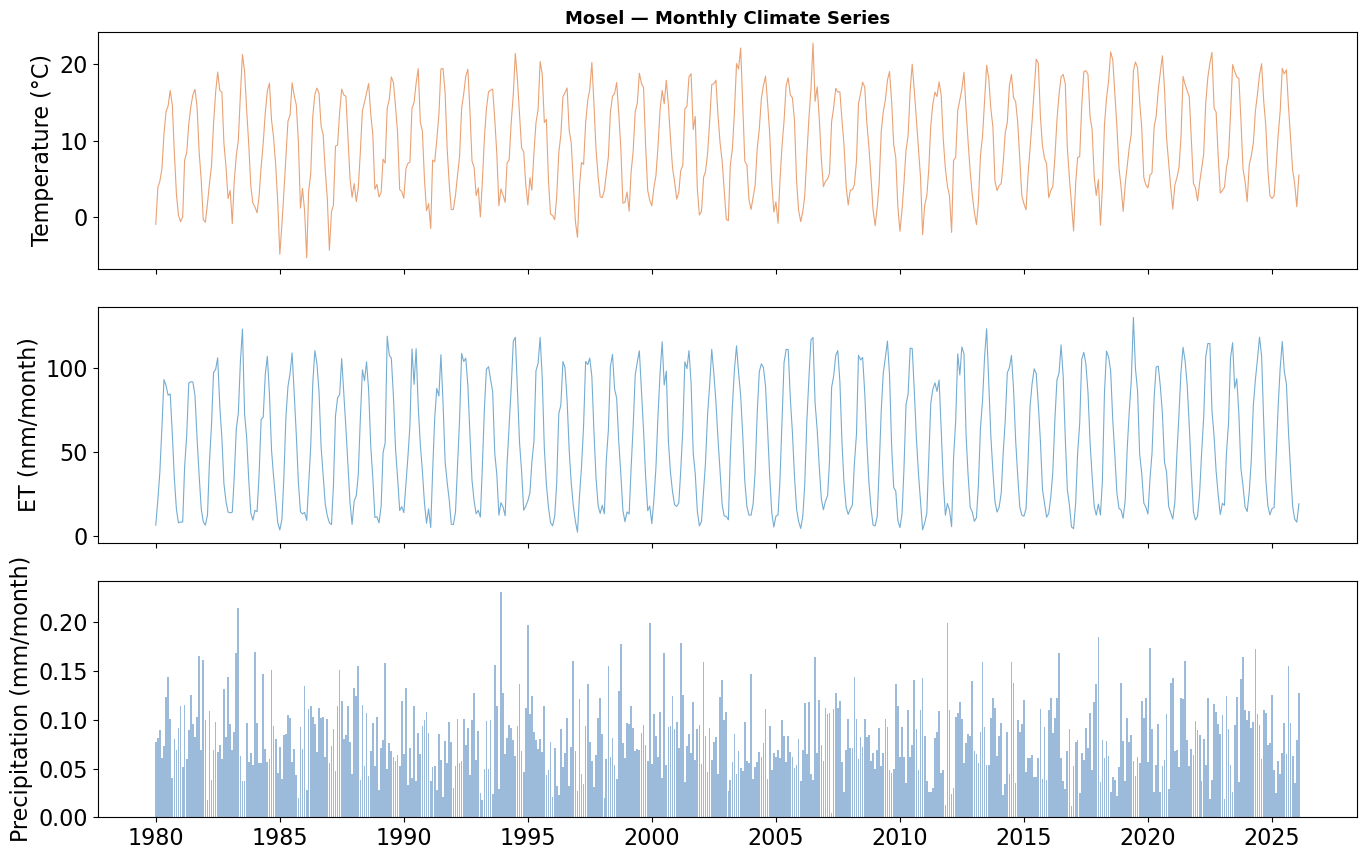

In [168]:
#checking the data 
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df['temp'], color='#e07b3a', lw=0.8, alpha=0.7)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Mosel — Monthly Climate Series', fontsize=13, fontweight='bold')

axes[1].plot(df.index, df['et'], color='#3a8abf', lw=0.8, alpha=0.7)
axes[1].set_ylabel('ET (mm/month)')

axes[2].bar(df.index, df['precip'], color='#5b8ec4', alpha=0.6, width=25)
axes[2].set_ylabel('Precipitation (mm/month)')

plt.tight_layout()
plt.show()

**Linear Regression**

=== Pooled linear regression: ET ~ Temperature ===
  Slope     : 4.977 mm/month per °C
  Intercept : 6.571
  R²        : 0.771
  p-value   : 1.00e-178
  Std error : 0.1155



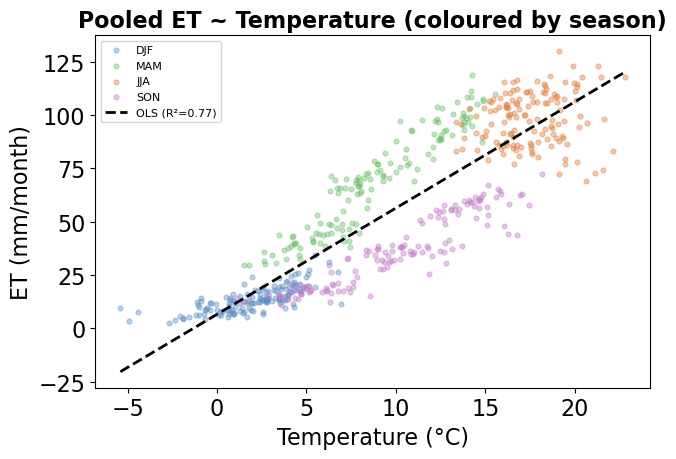

In [169]:
df['season'] = df['month'].apply(month_to_season)

def month_to_season(m):
    for season, months in SEASONS.items():
        if m in months:
            return season

df['season'] = df['month'].apply(month_to_season)

slope, intercept, r, p, se = stats.linregress(df['temp'], df['et'])

print('=== Pooled linear regression: ET ~ Temperature ===')
print(f'  Slope     : {slope:.3f} mm/month per °C')
print(f'  Intercept : {intercept:.3f}')
print(f'  R²        : {r**2:.3f}')
print(f'  p-value   : {p:.2e}')
print(f'  Std error : {se:.4f}')
print()

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
for s, sc in SEASON_COLORS.items():
    sub = df[df['season'] == s]
    ax.scatter(sub['temp'], sub['et'], color=sc, alpha=0.4, s=12, label=s)

x_line = np.linspace(df['temp'].min(), df['temp'].max(), 200)
ax.plot(x_line, intercept + slope * x_line, 'k--', lw=2, label=f'OLS (R²={r**2:.2f})')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('ET (mm/month)')
ax.set_title('Pooled ET ~ Temperature (coloured by season)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Per-season linear regression

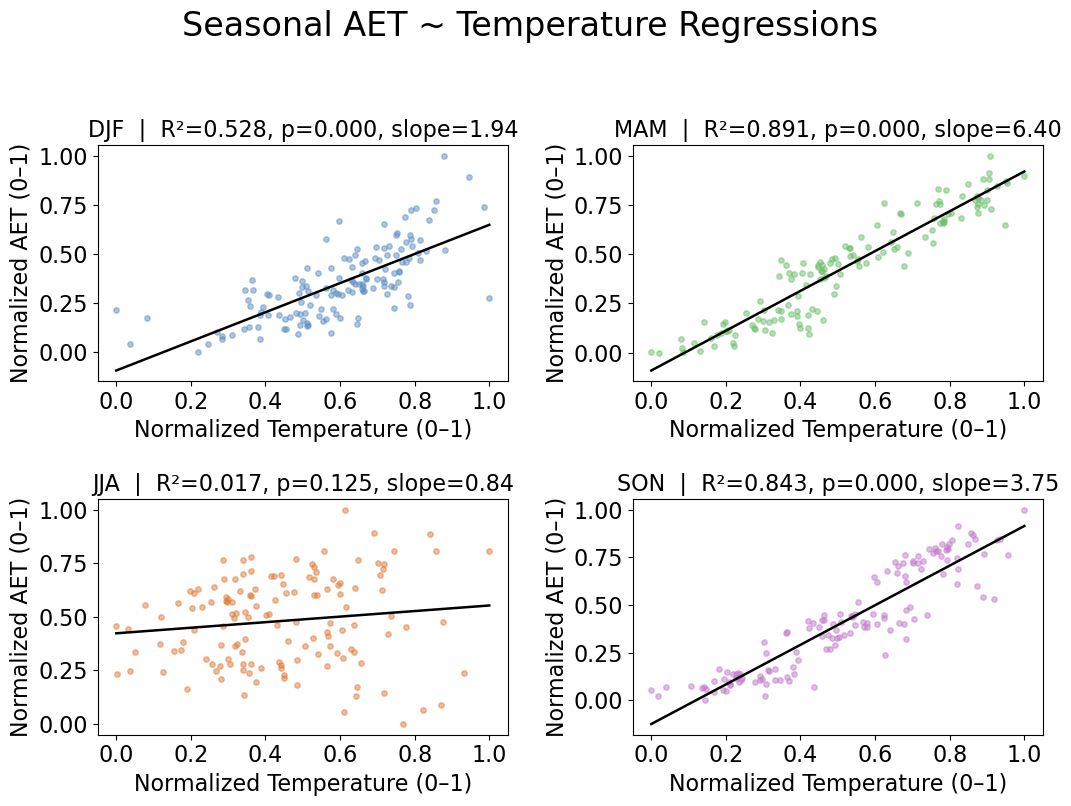


=== Seasonal regression summary ===
      slope  intercept      r2       p      se      n
DJF  1.9404     9.7951  0.5277  0.0000  0.1563  140.0
MAM  6.4022    12.1495  0.8912  0.0000  0.1918  138.0
JJA  0.8356    83.5219  0.0172  0.1252  0.5416  138.0
SON  3.7453    -0.8170  0.8430  0.0000  0.1386  138.0


In [170]:
results_seasonal = {}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, (season, color) in enumerate(SEASON_COLORS.items()):
    sub = df[df['season'] == season].copy()

    # Normalize temperature for plotting
    tmin, tmax = sub['temp'].min(), sub['temp'].max()
    sub['temp_norm'] = (sub['temp'] - tmin) / (tmax - tmin)

    # Normalize ET for plotting
    etmin, etmax = sub['et'].min(), sub['et'].max()
    sub['et_norm'] = (sub['et'] - etmin) / (etmax - etmin)

    # Regression still on original values
    sl, ic, r, p, se = stats.linregress(sub['temp'], sub['et'])
    results_seasonal[season] = dict(
        slope=sl, intercept=ic, r2=r**2, p=p, se=se, n=len(sub)
    )

    ax = axes[i]

    # Scatter using normalized values
    ax.scatter(sub['temp_norm'], sub['et_norm'], color=color, alpha=0.5, s=15)

    # Regression line 
    x_norm = np.linspace(0, 1, 100)
    x_orig = tmin + x_norm * (tmax - tmin)
    y_orig = ic + sl * x_orig
    y_norm = (y_orig - etmin) / (etmax - etmin)

    ax.plot(x_norm, y_norm, 'k-', lw=1.8)

    # Titles and labels now use rcParams defaults
    ax.set_title(f'{season}  |  R²={r**2:.3f}, p={p:.3f}, slope={sl:.2f}')
    ax.set_xlabel('Normalized Temperature (0–1)')
    ax.set_ylabel('Normalized AET (0–1)')

plt.suptitle('Seasonal AET ~ Temperature Regressions',
             fontweight='normal', y=1.02)

plt.tight_layout()
plt.savefig("Thin Seasonal Regression Normalized Both Axes.png", dpi=300, bbox_inches="tight")
plt.show()

print('\n=== Seasonal regression summary ===')
print(pd.DataFrame(results_seasonal).T.round(4))


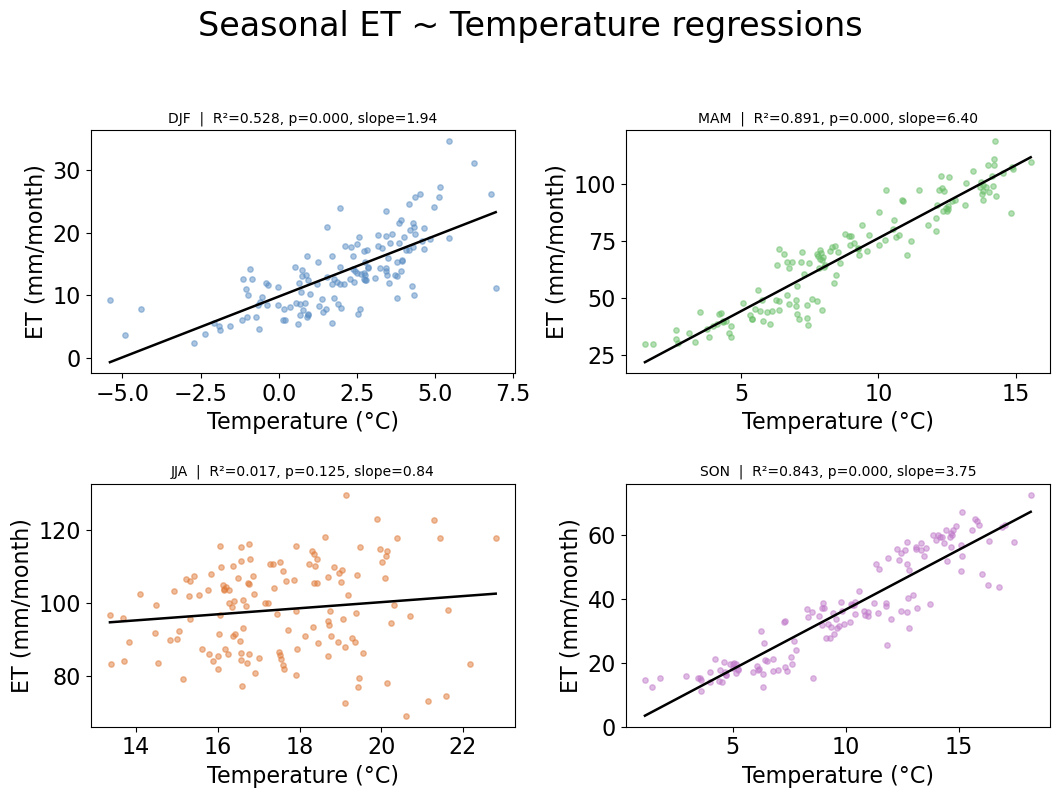


=== Seasonal regression summary ===
      slope  intercept      r2       p      se      n
DJF  1.9404     9.7951  0.5277  0.0000  0.1563  140.0
MAM  6.4022    12.1495  0.8912  0.0000  0.1918  138.0
JJA  0.8356    83.5219  0.0172  0.1252  0.5416  138.0
SON  3.7453    -0.8170  0.8430  0.0000  0.1386  138.0


In [172]:
results_seasonal = {}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, (season, color) in enumerate(SEASON_COLORS.items()):
    sub = df[df['season'] == season].copy()
    sl, ic, r, p, se = stats.linregress(sub['temp'], sub['et'])
    results_seasonal[season] = dict(slope=sl, intercept=ic, r2=r**2, p=p, se=se, n=len(sub))

    ax = axes[i]
    ax.scatter(sub['temp'], sub['et'], color=color, alpha=0.5, s=15)
    x_l = np.linspace(sub['temp'].min(), sub['temp'].max(), 100)
    ax.plot(x_l, ic + sl * x_l, 'k-', lw=1.8)
    ax.set_title(f'{season}  |  R²={r**2:.3f}, p={p:.3f}, slope={sl:.2f}', fontsize=10)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('ET (mm/month)')

plt.suptitle('Seasonal ET ~ Temperature regressions', fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig("Seasonal Regression.png", dpi=300, bbox_inches="tight")

plt.show()


print('\n=== Seasonal regression summary ===')
print(pd.DataFrame(results_seasonal).T.round(4))

###  Bootstrap confidence intervals on seasonal slopes

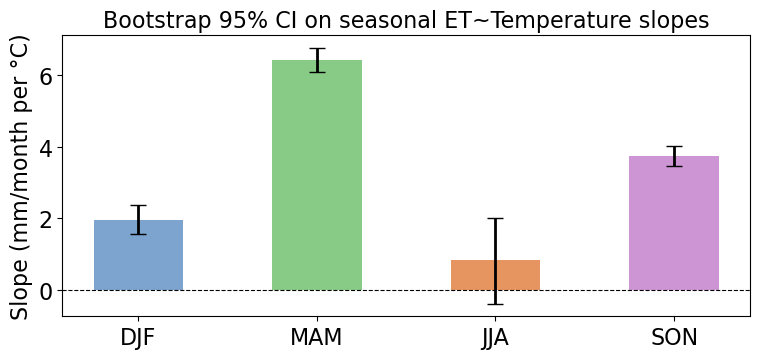


=== Bootstrap results (95% CI) ===
  DJF: slope = 1.952  [1.555, 2.362]
  MAM: slope = 6.406  [6.074, 6.742]
  JJA: slope = 0.834  [-0.369, 2.021]
  SON: slope = 3.748  [3.458, 4.030]


In [152]:
N_BOOT = 2000

boot_results = {}
for season in SEASONS:
    sub = df[df['season'] == season][['temp', 'et']].dropna().values
    slopes_boot = []
    for _ in range(N_BOOT):
        s = resample(sub)
        sl, *_ = stats.linregress(s[:, 0], s[:, 1])
        slopes_boot.append(sl)
    slopes_boot = np.array(slopes_boot)
    boot_results[season] = {
        'mean': slopes_boot.mean(),
        'ci_lo': np.percentile(slopes_boot, 2.5),
        'ci_hi': np.percentile(slopes_boot, 97.5),
        'slopes': slopes_boot
    }

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(SEASONS))
for i, (season, color) in enumerate(SEASON_COLORS.items()):
    br = boot_results[season]
    ax.bar(i, br['mean'], color=color, alpha=0.8, width=0.5)
    ax.errorbar(i, br['mean'],
                yerr=[[br['mean'] - br['ci_lo']], [br['ci_hi'] - br['mean']]],
                fmt='none', color='black', capsize=6, lw=2)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(list(SEASON_COLORS.keys()))
ax.set_ylabel('Slope (mm/month per °C)')
ax.set_title('Bootstrap 95% CI on seasonal ET~Temperature slopes', fontweight='normal')
plt.tight_layout()
plt.savefig("Bootstrap.png", dpi=300, bbox_inches="tight")
plt.show()

print('\n=== Bootstrap results (95% CI) ===')
for s, br in boot_results.items():
    print(f'  {s}: slope = {br["mean"]:.3f}  [{br["ci_lo"]:.3f}, {br["ci_hi"]:.3f}]')

---
## Partial correlation/controlling for the seasonal cycle

=== Partial correlation (anomalies, seasonal cycle removed) ===
  Slope     : 2.175 mm/month per °C anomaly
  R²        : 0.318
  p-value   : 0.0000

 Significant interannual temperature–ET relationship after removing seasonal cycle.


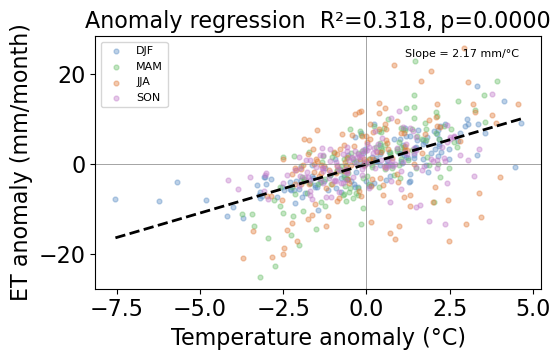

In [173]:
# Compute monthly climatology and anomalies
clim_mean = df.groupby('month')[['temp', 'et']].transform('mean')
df['temp_anom'] = df['temp'] - clim_mean['temp']
df['et_anom']   = df['et']   - clim_mean['et']

# Regression on anomalies
sl, ic, r, p, se = stats.linregress(df['temp_anom'], df['et_anom'])

print('=== Partial correlation (anomalies, seasonal cycle removed) ===')
print(f'  Slope     : {sl:.3f} mm/month per °C anomaly')
print(f'  R²        : {r**2:.3f}')
print(f'  p-value   : {p:.4f}')
print()
if r**2 > 0.05 and p < 0.05:
    print(' Significant interannual temperature–ET relationship after removing seasonal cycle.')
else:
    print('  Weak or non-significant after removing seasonal cycle. The pooled R² was likely inflated.')

# Single-panel figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Anomaly scatter
for s, sc in SEASON_COLORS.items():
    sub = df[df['season'] == s]
    ax.scatter(sub['temp_anom'], sub['et_anom'], color=sc, alpha=0.4, s=12, label=s)

# Regression line
x_l = np.linspace(df['temp_anom'].min(), df['temp_anom'].max(), 200)
ax.plot(x_l, ic + sl * x_l, 'k--', lw=2)

# Zero lines
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.text(
    0.95, 0.95,
    f"Slope = {sl:.2f} mm/°C",
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=8
)

# Labels and title
ax.set_xlabel('Temperature anomaly (°C)')
ax.set_ylabel('ET anomaly (mm/month)')
ax.set_title(f'Anomaly regression  R²={r**2:.3f}, p={p:.4f}', fontweight='normal')



# Legend
ax.legend(fontsize=8)

# Layout, save, show
plt.tight_layout()
plt.savefig("Anomaly_regression.png", dpi=300, bbox_inches="tight")
plt.show()


In [45]:
# Formal regression controlling for month fixed effects
df_ols = df[['et', 'temp', 'month']].copy()
df_ols['month'] = df_ols['month'].astype('category')

model = smf.ols('et ~ temp + C(month)', data=df_ols).fit()

print('=== OLS with month fixed effects ===')
print(f'  temp coefficient : {model.params["temp"]:.4f}')
print(f'  p-value (temp)   : {model.pvalues["temp"]:.4f}')
print(f'  R² (full model)  : {model.rsquared:.4f}')
print(f'  AIC              : {model.aic:.2f}')
print()
print(model.summary().tables[1])

=== OLS with month fixed effects ===
  temp coefficient : 2.1748
  p-value (temp)   : 0.0000
  R² (full model)  : 0.9745
  AIC              : 3530.07

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.0954      0.863     10.544      0.000       7.401      10.790
C(month)[T.2]      3.3299      1.199      2.777      0.006       0.974       5.685
C(month)[T.3]     20.5337      1.315     15.620      0.000      17.951      23.116
C(month)[T.4]     42.0451      1.557     27.000      0.000      38.986      45.104
C(month)[T.5]     58.8347      1.978     29.744      0.000      54.949      62.720
C(month)[T.6]     59.4904      2.369     25.116      0.000      54.838      64.143
C(month)[T.7]     55.7366      2.613     21.328      0.000      50.603      60.870
C(month)[T.8]     37.6132      2.599     14.471      0.000      32.507      42.719
C(month)[T.9]     1


## **Nonlinear regression**

Hamon-like: a=6.949, T0=-0.17, b=0.906, R²=0.774
Polynomial deg 2: R²=0.771


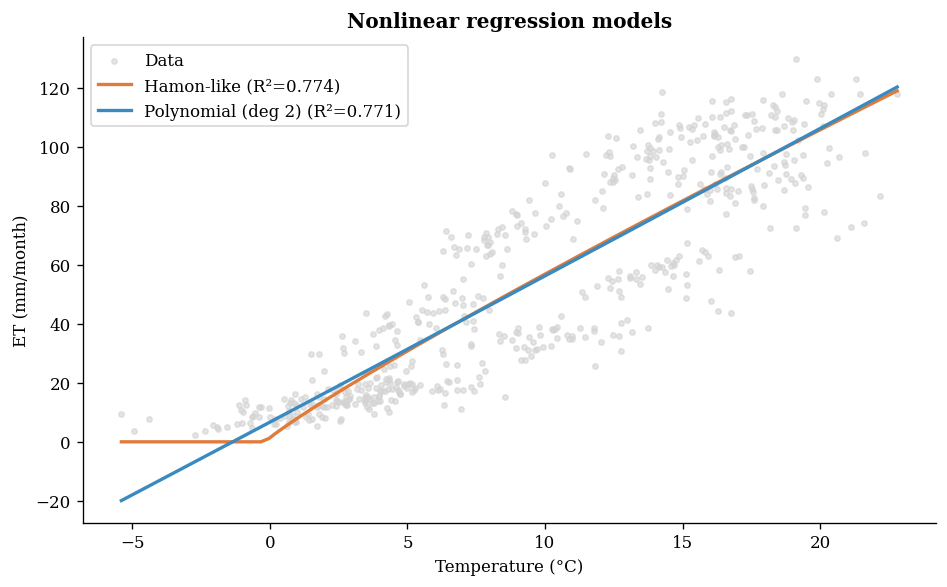

In [46]:
# --- Model functions ---
def hamon_like(T, a, T0, b):
    """ET ~ a * max(T - T0, 0)^b  — Hamon-inspired"""
    return a * np.maximum(T - T0, 0) ** b

def exponential_model(T, a, b):
    return a * np.exp(b * T)

def polynomial_model(T, a, b, c):
    return a * T**2 + b * T + c

T_data = df['temp'].values
ET_data = df['et'].values
sort_idx = np.argsort(T_data)
T_sorted = T_data[sort_idx]

fit_results = {}

# Hamon-like
try:
    popt, pcov = curve_fit(hamon_like, T_data, ET_data, p0=[3.5, 0, 0.7],
                           bounds=([0, -5, 0.1], [20, 10, 3]), maxfev=5000)
    et_pred = hamon_like(T_sorted, *popt)
    ss_res = np.sum((ET_data - hamon_like(T_data, *popt))**2)
    ss_tot = np.sum((ET_data - ET_data.mean())**2)
    fit_results['Hamon-like'] = dict(popt=popt, r2=1 - ss_res/ss_tot, pred=et_pred)
    print(f'Hamon-like: a={popt[0]:.3f}, T0={popt[1]:.2f}, b={popt[2]:.3f}, R²={1-ss_res/ss_tot:.3f}')
except Exception as e:
    print(f'Hamon fit failed: {e}')

# Polynomial degree 2
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_model.fit(T_data.reshape(-1, 1), ET_data)
et_poly = poly_model.predict(T_sorted.reshape(-1, 1))
r2_poly = poly_model.score(T_data.reshape(-1, 1), ET_data)
fit_results['Polynomial (deg 2)'] = dict(r2=r2_poly, pred=et_poly)
print(f'Polynomial deg 2: R²={r2_poly:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(T_data, ET_data, color='lightgray', s=10, alpha=0.6, label='Data')
colors_nl = ['#e07b3a', '#3a8abf', '#6abf69']
for (name, res), col in zip(fit_results.items(), colors_nl):
    ax.plot(T_sorted, res['pred'], color=col, lw=2, label=f'{name} (R²={res["r2"]:.3f})')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('ET (mm/month)')
ax.set_title('Nonlinear regression models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## Mutual information/ detecting nonlinear dependence

=== Mutual Information vs Linear Correlation ===
  feature  mutual_info  abs_linear_corr
     temp       1.0262           0.8780
temp_anom       0.1971           0.1090
   precip       0.0649           0.0687

If MI >> linear corr for temp_anom, there is nonlinear signal beyond what linear regression captures.


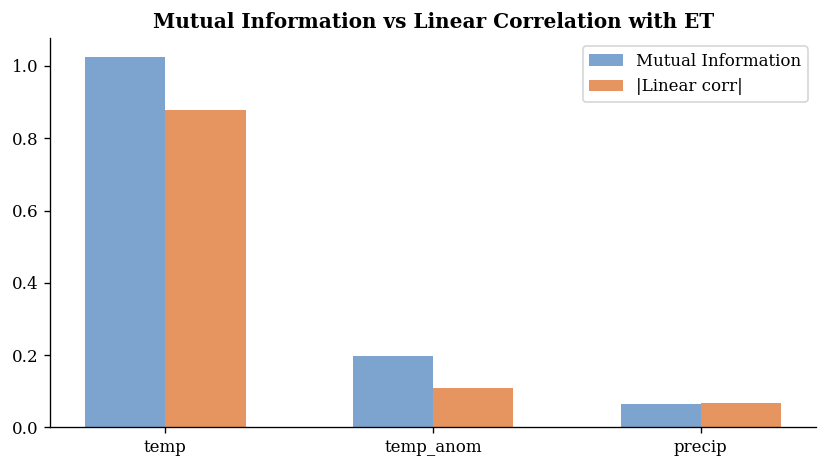

In [47]:
# Compare mutual information (any dependence) vs linear correlation
features = ['temp', 'temp_anom', 'precip']
X = df[features].dropna().values
y = df.loc[df[features].dropna().index, 'et'].values

mi = mutual_info_regression(X, y, random_state=42)
corr_linear = [abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(X.shape[1])]

mi_df = pd.DataFrame({
    'feature': features,
    'mutual_info': mi,
    'abs_linear_corr': corr_linear
})

print('=== Mutual Information vs Linear Correlation ===')
print(mi_df.round(4).to_string(index=False))
print()
print('If MI >> linear corr for temp_anom, there is nonlinear signal beyond what linear regression captures.')

fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(len(features))
w = 0.3
ax.bar(x_pos - w/2, mi_df['mutual_info'], width=w, label='Mutual Information', color='#5b8ec4', alpha=0.8)
ax.bar(x_pos + w/2, mi_df['abs_linear_corr'], width=w, label='|Linear corr|', color='#e07b3a', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(features)
ax.set_title('Mutual Information vs Linear Correlation with ET', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()